# 🚲 Cycling Exposure & Counter Validation

**Part 3 of 3.** [`01_eda_and_analysis.ipynb`](01_eda_and_analysis.ipynb) explores the
accidents; [`02_OSM_Berlin_Street_Risk_Analysis.ipynb`](02_OSM_Berlin_Street_Risk_Analysis.ipynb)
maps them onto the road network. Both share one blind spot.

The Unfallatlas records **only accidents**. It contains no record of a trip that
ended safely, and no count of how many people cycled anywhere. So every
accident-based statistic measures two things at once:

$$\text{accidents} = \underbrace{\text{risk}}_{\text{what we want}} \times \underbrace{\text{exposure}}_{\text{how many people ride}}$$

This notebook adds the missing denominator using Berlin's **automatic bicycle
counters** (Senatsverwaltung für Mobilität und Verkehr): 35 permanent sensors
recording hourly volumes since 2012.

It does two separate things:

1. **A citywide temporal index** — corrects the hour-of-day and seasonal
   patterns from notebook 01. Applies everywhere, because it describes *when*
   people ride rather than *where*.
2. **Per-passage risk at 24 sites** — the only locations in Berlin where risk
   can be given a true denominator: accidents per million cyclist-passages.

> **What this cannot do.** 35 counters against ~239,000 road segments is 0.015%
> coverage, so it cannot supply per-segment exposure and cannot turn the
> pseudo-negative samples in the ML pipeline into real negatives. Claims about
> individual segments still rest on shrinkage, not measurement.

## Contents
1. [Setup](#1-setup)
2. [Counter Locations](#2-locations)
3. [Cyclist Volume per Site](#3-volume)
4. [Matching Accidents to Counters](#4-matching)
5. [Risk per Million Passages](#5-risk)
6. [Interpretation](#6-interpretation)
7. [Limitations](#7-limitations)

---
## 1. Setup <a id='1-setup'></a>

`gesamtdatei-stundenwerte.xlsx` is ~18 MB and is **not committed** to the
repository. Download it from the
[Berlin counter data page](https://www.berlin.de/sen/uvk/mobilitaet-und-verkehr/verkehrsplanung/radverkehr/weitere-radinfrastruktur/zaehlstellen-und-fahrradbarometer/)
and place it in `data/raw/`.

The workbook has one sheet per year plus a `Standortdaten` sheet holding each
site's coordinates and commissioning date.

In [1]:
import datetime as dt
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

# Search a few plausible locations so the notebook runs from repo root or /notebooks
XLSX_CANDIDATES = [
    Path("data/raw/gesamtdatei-stundenwerte.xlsx"),
    Path("../data/raw/gesamtdatei-stundenwerte.xlsx"),
    Path("/mnt/user-data/uploads/gesamtdatei-stundenwerte.xlsx"),
]
ACC_CANDIDATES = [
    Path("data/processed/berlin_bike_2018_2025.csv"),
    Path("../data/processed/berlin_bike_2018_2025.csv"),
    Path("/mnt/user-data/uploads/berlin_bike_2018_2025.csv"),
]

XLSX = next((p for p in XLSX_CANDIDATES if p.exists()), None)
ACC = next((p for p in ACC_CANDIDATES if p.exists()), None)
if XLSX is None or ACC is None:
    raise FileNotFoundError("Counter workbook or clean accident file not found.")

YEARS = range(2018, 2026)      # match the accident data window
RADII = (30, 50, 100)          # accident search radii around each counter, metres
MIN_HOURS = 6000               # a counter-year needs most of its hours present
MIN_YEARS = 6                  # and a site needs a comparable multi-year window

print(f"counter workbook : {XLSX}")
print(f"accident file    : {ACC}")

wb = openpyxl.load_workbook(XLSX, read_only=True, data_only=True)
print(f"sheets           : {len(wb.sheetnames)} ({wb.sheetnames[3]} ... {wb.sheetnames[-1]})")

counter workbook : ..\data\raw\gesamtdatei-stundenwerte.xlsx
accident file    : ..\data\processed\berlin_bike_2018_2025.csv
sheets           : 17 (Jahresdatei 2012 ... Jahresdatei 2025)


---
## 2. Counter Locations <a id='2-locations'></a>

Two details in the source data need handling.

**Inconsistent separators.** Column headers in the yearly sheets combine the
site code with its commissioning date, but some use a newline and others a
space (`"02-MI-JAN-N\n01.04.2015"` vs `"02-MI-JAN-N 01.04.2015"`). Splitting on
whitespace generally handles both; splitting on `\n` silently loses half of them.

**A typo in the source.** Two sites appear as `17-SK-BRE-*` in `Standortdaten`
but `17-SZ-BRE-*` in the data sheets. Without correcting this they drop out of
the join.

In [2]:
rows = list(wb["Standortdaten"].iter_rows(values_only=True))
meta = pd.DataFrame(rows[1:], columns=[str(c).strip() for c in rows[0]])

meta = meta.rename(columns={
    "Zählstelle": "counter",
    "Beschreibung - Fahrtrichtung": "description",
    "Breitengrad": "lat",
    "Längengrad": "lon",
    "Installationsdatum": "installed",
})

# Site code only, and repair the SK/SZ inconsistency against the data sheets.
meta["counter"] = (
    meta["counter"].astype(str).str.split().str[0].str.strip()
    .str.replace("17-SK-", "17-SZ-", regex=False)
)
meta["lat"] = pd.to_numeric(meta["lat"], errors="coerce")
meta["lon"] = pd.to_numeric(meta["lon"], errors="coerce")
meta = meta.dropna(subset=["lat", "lon"]).drop_duplicates("counter")

print(f"{len(meta)} counter sites with coordinates")
meta[["counter", "description", "lat", "lon", "installed"]].head(8)

35 counter sites with coordinates


,counter,description,lat,lon,installed
0,12-PA-SCH,Schwedter Steg,52.549071,13.400367,2012-03-01
1,02-MI-JAN-N,Jannowitzbrücke Nord,52.513932,13.417835,2015-04-01
2,02-MI-JAN-S,Jannowitzbrücke Süd,52.513943,13.417611,2015-04-01
3,13-CW-PRI,Prinzregentenstraße,52.488136,13.333120,2015-04-01
4,18-TS-YOR-O,Yorckstraße Ost,52.491938,13.373472,2015-04-01
5,18-TS-YOR-W,Yorkstraße West,52.492280,13.373210,2015-04-01
6,19-TS-MON,Monumentenstraße,52.488117,13.369785,2015-05-01
7,27-RE-MAR,Markstraße,52.558190,13.364944,2015-05-01


---
## 3. Cyclist Volume per Site <a id='3-volume'></a>

Per the workbook's `Legende` sheet, a blank cell means "no data" and a **`0`
means "no or implausible data"** — not zero traffic. Both are treated as
missing; counting zeros as real would inflate the denominator and understate
risk.

Counters were commissioned between 2012 and 2024, so sites are only comparable
over a shared window. We keep sites with at least six near-complete years
inside 2018–2025.

In [3]:
totals, coverage = {}, {}

for year in YEARS:
    ws = wb[f"Jahresdatei {year}"]
    it = ws.iter_rows(values_only=True)
    header = next(it)
    # split() handles both the newline- and space-separated header variants
    names = [str(h).split()[0].strip() if h else f"col{i}" for i, h in enumerate(header)]
    data = [r for r in it if r and isinstance(r[0], dt.datetime)]

    df = pd.DataFrame(data, columns=names).iloc[:, 1:]
    df = df.apply(pd.to_numeric, errors="coerce").replace(0, np.nan)

    for site in df.columns:
        series = df[site].dropna()
        if len(series) < MIN_HOURS:
            continue
        totals[site] = totals.get(site, 0.0) + series.sum()
        coverage[site] = coverage.get(site, 0) + 1

volume = pd.DataFrame({
    "counter": list(totals),
    "passages": list(totals.values()),
    "years_covered": [coverage[s] for s in totals],
})
volume = volume[volume.years_covered >= MIN_YEARS]
volume["passages_M"] = (volume.passages / 1e6).round(2)

print(f"{len(volume)} sites with >= {MIN_YEARS} near-complete years in {min(YEARS)}-{max(YEARS)}")
volume.sort_values("passages", ascending=False).head(8)

24 sites with >= 6 near-complete years in 2018-2025


,counter,passages,years_covered,passages_M
21,21-NK-MAY,13899928.0,8,13.90
0,02-MI-JAN-N,10867400.0,8,10.87
1,02-MI-JAN-S,10484700.0,8,10.48
18,19-TS-MON,10110638.0,8,10.11
8,10-PA-BER-N,8719083.0,8,8.72
24,26-LI-PUP,8293842.0,8,8.29
9,10-PA-BER-S,7872970.0,8,7.87
17,18-TS-YOR-W,7695758.0,8,7.70


---
## 4. Matching Accidents to Counters <a id='4-matching'></a>

Counters and accidents are both points, so no road graph is needed. Distances
use a local metric approximation: one degree of latitude is ~111,320 m, and one
degree of longitude is that scaled by cos(52.52°) at Berlin's latitude. Over the
tens of metres involved the error is negligible.

Three radii are computed so the ranking can be checked for stability rather
than resting on one arbitrary threshold.

In [4]:
accidents = pd.read_csv(ACC)
accidents = accidents[accidents.year.between(min(YEARS), max(YEARS))]

if "serious_or_fatal" not in accidents.columns:
    if "accident_severity" in accidents.columns:
        accidents["serious_or_fatal"] = accidents["accident_severity"].isin([1, 2]).astype(int)
    elif "severity_label" in accidents.columns:
        accidents["serious_or_fatal"] = (
            accidents["severity_label"].isin(["fatal", "serious_injury"]).astype(int)
        )
    else:
        raise KeyError(f"No severity column. Available: {list(accidents.columns)}")

print("serious_or_fatal present:", "serious_or_fatal" in accidents.columns)
print(f"{len(accidents):,} accidents | KSI: {accidents.serious_or_fatal.sum():,}")

serious_or_fatal present: True
37,948 accidents | KSI: 4,930


In [5]:
accidents = pd.read_csv(ACC)
accidents = accidents[accidents.year.between(min(YEARS), max(YEARS))]
if "serious_or_fatal" not in accidents.columns:
    if "accident_severity" in accidents.columns:
        # Unfallatlas UKATEGORIE: 1 = fatal, 2 = serious, 3 = minor
        accidents["serious_or_fatal"] = accidents["accident_severity"].isin([1, 2]).astype(int)
    elif "severity_label" in accidents.columns:
        accidents["serious_or_fatal"] = (
            accidents["severity_label"].isin(["fatal", "serious_injury"]).astype(int)
        )
    else:
        raise KeyError(f"No severity column found. Available: {list(accidents.columns)}")
print(f"{len(accidents):,} bicycle accidents {min(YEARS)}-{max(YEARS)}")

sites = meta.merge(volume, on="counter", how="inner")
print(f"{len(sites)} sites with both coordinates and volume")

LAT_M = 111_320.0
LON_M = 111_320.0 * np.cos(np.radians(52.52))

for radius in RADII:
    near_counts, near_ksi = [], []
    for _, site in sites.iterrows():
        dx = (accidents.longitude - site.lon) * LON_M
        dy = (accidents.latitude - site.lat) * LAT_M
        within = (dx**2 + dy**2) <= radius**2
        near_counts.append(int(within.sum()))
        near_ksi.append(int(accidents.loc[within, "serious_or_fatal"].sum()))
    sites[f"acc_{radius}m"] = near_counts
    sites[f"ksi_{radius}m"] = near_ksi

sites[["counter", "description", "passages_M"] +
      [f"acc_{r}m" for r in RADII]].head(8)

37,948 bicycle accidents 2018-2025
24 sites with both coordinates and volume


,counter,description,passages_M,acc_30m,acc_50m,acc_100m
0,12-PA-SCH,Schwedter Steg,6.62,0,0,1
1,02-MI-JAN-N,Jannowitzbrücke Nord,10.87,11,11,17
2,02-MI-JAN-S,Jannowitzbrücke Süd,10.48,11,11,17
3,13-CW-PRI,Prinzregentenstraße,4.45,0,6,9
4,18-TS-YOR-O,Yorckstraße Ost,7.15,1,2,5
5,18-TS-YOR-W,Yorkstraße West,7.70,3,3,6
6,19-TS-MON,Monumentenstraße,10.11,2,2,4
7,27-RE-MAR,Markstraße,4.11,11,29,33


---
## 5. Risk per Million Passages <a id='5-risk'></a>

$$\text{risk}_i = \frac{\text{accidents within 50 m}}{\text{million cyclist-passages}}$$

This is the quantity the accident data alone cannot produce. Unlike the
shrinkage-based score in notebook 02, it needs no prior and no assumption —
it is a measured rate.

In [6]:
R = 50
sites["acc_per_Mpass"] = (sites[f"acc_{R}m"] / (sites.passages / 1e6)).round(2)
sites["ksi_per_Mpass"] = (sites[f"ksi_{R}m"] / (sites.passages / 1e6)).round(3)

result = sites[["counter", "description", "passages_M", "years_covered",
                f"acc_{R}m", f"ksi_{R}m", "acc_per_Mpass", "ksi_per_Mpass"]].copy()
result["rank_raw"] = result[f"acc_{R}m"].rank(ascending=False).astype(int)
result["rank_rate"] = result["acc_per_Mpass"].rank(ascending=False).astype(int)
result["rank_shift"] = result.rank_raw - result.rank_rate
result = result.sort_values("acc_per_Mpass", ascending=False).reset_index(drop=True)

rho = result[f"acc_{R}m"].corr(result.acc_per_Mpass, method="spearman")
print(f"Spearman(raw accident count, accidents per passage) = {rho:.3f}")
print(f"median = {result.acc_per_Mpass.median():.2f} per million passages")
result

Spearman(raw accident count, accidents per passage) = 0.747
median = 0.62 per million passages


,counter,description,passages_M,years_covered,acc_50m,ksi_50m,acc_per_Mpass,ksi_per_Mpass,rank_raw,rank_rate,rank_shift
0,27-RE-MAR,Markstraße,4.11,8,29,6,7.05,1.458,1,1,0
1,15-SP-KLO-S,Klosterstraße Süd,2.17,8,7,1,3.22,0.461,5,2,3
2,17-SZ-BRE-O,Breitenbachplatz Ost,3.46,8,7,1,2.02,0.289,5,3,2
3,13-CW-PRI,Prinzregentenstraße,4.45,8,6,0,1.35,0.000,8,4,4
4,06-FK-FRA-W,Frankfurter Allee West,6.04,8,7,0,1.16,0.000,5,5,0
5,20-TS-MAR-S,Mariendorfer Damm Süd,1.82,8,2,0,1.10,0.000,16,6,10
6,06-FK-FRA-O,Frankfurter Allee Ost,6.45,8,7,0,1.09,0.000,5,7,-2
7,02-MI-JAN-S,Jannowitzbrücke Süd,10.48,8,11,2,1.05,0.191,2,8,-6
8,02-MI-JAN-N,Jannowitzbrücke Nord,10.87,8,11,2,1.01,0.184,2,9,-7
9,03-MI-SAN-O,Invalidenstraße Ost,5.24,7,4,0,0.76,0.000,10,10,0


### 5.1 Is the ranking stable across search radii?

A conclusion that only holds at 50 m is an artefact of the threshold.

In [7]:
stability = pd.DataFrame({
    f"per_Mpass_{r}m": (sites[f"acc_{r}m"] / (sites.passages / 1e6)).round(2)
    for r in RADII
})
stability.index = sites.counter.to_numpy()   # assign after, not via index=

print("Spearman correlation between radii:")
print(stability.corr(method="spearman").round(3).to_string())
stability.sort_values(f"per_Mpass_{R}m", ascending=False).head(8)

Spearman correlation between radii:
                per_Mpass_30m  per_Mpass_50m  per_Mpass_100m
per_Mpass_30m           1.000          0.533           0.322
per_Mpass_50m           0.533          1.000           0.674
per_Mpass_100m          0.322          0.674           1.000


,per_Mpass_30m,per_Mpass_50m,per_Mpass_100m
27-RE-MAR,2.67,7.05,8.02
15-SP-KLO-S,0.46,3.22,7.37
17-SZ-BRE-O,0.00,2.02,4.05
13-CW-PRI,0.00,1.35,2.02
06-FK-FRA-W,0.66,1.16,3.31
20-TS-MAR-S,1.10,1.10,6.59
06-FK-FRA-O,0.47,1.09,2.95
02-MI-JAN-S,1.05,1.05,1.62


### 5.2 Raw counts versus exposure-adjusted rate

The gap between the two bars is the effect of the denominator.

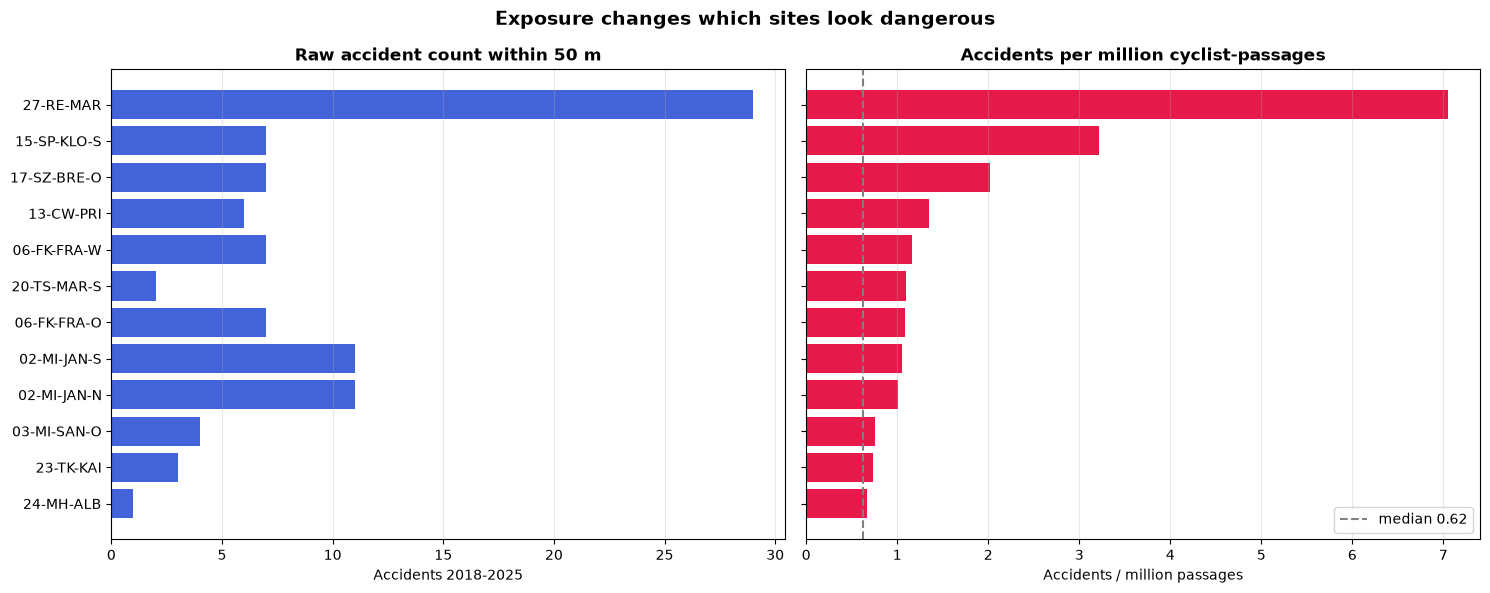

In [11]:
from pathlib import Path

FIG_DIR = next(
    (p for p in [Path("outputs/figures"), Path("../outputs/figures")] if p.parent.exists()),
    Path("outputs/figures"),
)
FIG_DIR.mkdir(parents=True, exist_ok=True)

top = result.head(12).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

axes[0].barh(top.counter, top[f"acc_{R}m"], color="#4363d8")
axes[0].set_title(f"Raw accident count within {R} m", fontweight="bold")
axes[0].set_xlabel("Accidents 2018-2025")

axes[1].barh(top.counter, top.acc_per_Mpass, color="#e6194b")
axes[1].set_title("Accidents per million cyclist-passages", fontweight="bold")
axes[1].set_xlabel("Accidents / million passages")
axes[1].axvline(result.acc_per_Mpass.median(), ls="--", c="grey",
                label=f"median {result.acc_per_Mpass.median():.2f}")
axes[1].legend()

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("Exposure changes which sites look dangerous", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "counter_risk_per_passage.png", dpi=150, bbox_inches="tight")
plt.show()

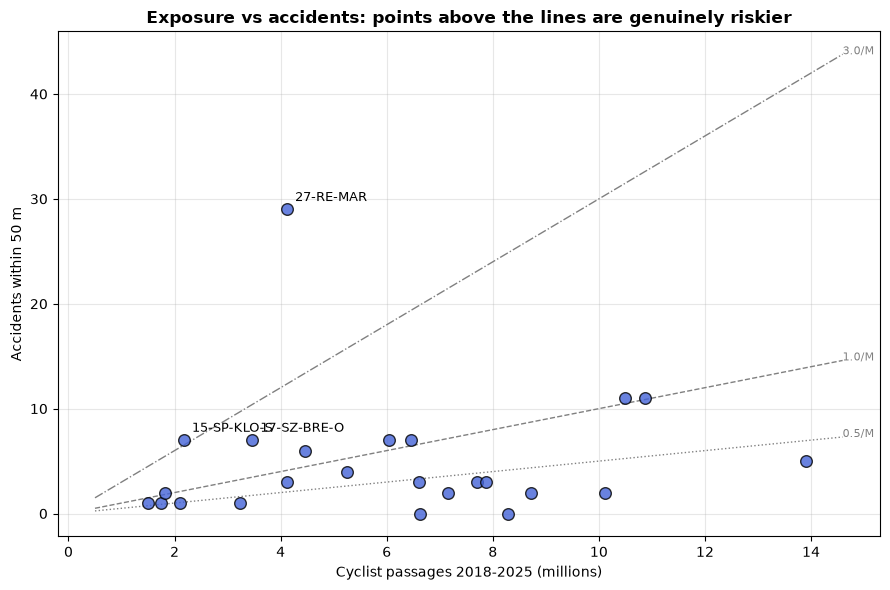

In [12]:
from pathlib import Path

FIG_DIR = next(
    (p for p in [Path("outputs/figures"), Path("../outputs/figures")] if p.parent.exists()),
    Path("outputs/figures"),
)
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sites.passages / 1e6, sites[f"acc_{R}m"], s=70,
           c="#4363d8", edgecolor="black", alpha=0.8, zorder=3)

# iso-risk lines: constant accidents per million passages
x = np.linspace(0.5, sites.passages.max() / 1e6 * 1.05, 100)
for rate, style in [(0.5, ":"), (1.0, "--"), (3.0, "-.")]:
    ax.plot(x, rate * x, style, c="grey", lw=1)
    ax.annotate(f"{rate}/M", (x[-1], rate * x[-1]), fontsize=8, color="grey")

for _, r in sites.nlargest(3, "acc_per_Mpass").iterrows():
    ax.annotate(r.counter, (r.passages / 1e6, r[f"acc_{R}m"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.set_xlabel("Cyclist passages 2018-2025 (millions)")
ax.set_ylabel(f"Accidents within {R} m")
ax.set_title("Exposure vs accidents: points above the lines are genuinely riskier",
             fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "counter_exposure_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Interpretation <a id='6-interpretation'></a>

**The denominator reorders the ranking.** Spearman between raw counts and
per-passage rates is about 0.75 — broadly similar, but disagreeing exactly where
it matters. Berlin's busiest cycling crossings accumulate accidents by carrying
enormous numbers of cyclists, not necessarily by being dangerous. Conversely,
several low-volume sites carry a high rate and are invisible in raw counts.

**Reinickendorf (`27-RE-MAR`) is the clearest finding**: roughly 7x the median
rate, and the only site whose accident count is large enough to stand on its own
statistically.

**How this relates to the ML model.** Tested directly, the temporal exposure
index adds nothing as a model feature (holdout PR-AUC 0.8627 with it, 0.8630
without, 0.8607 for road features alone — all within noise). That is expected: a
citywide temporal multiplier is constant across segments at a given hour, so it
cannot discriminate between them. Exposure belongs here, as an analytical
correction and a validation set, and statistically as the *offset* in a rate
model — not as a classifier feature.

**Suggested next step.** Join the segment risk scores from notebook 02 to these
24 coordinates and correlate them against `acc_per_Mpass`. That tests whether
the shrinkage-based score tracks measured per-cyclist risk, and converts "we
lack exposure data" into a number.

---
## 7. Limitations <a id='7-limitations'></a>

**1. Small counts.** Most sites record 0–11 accidents in eight years. A rate
built on 2 accidents has a very wide confidence interval; only Reinickendorf's
count is large enough to quote alone. Treat the ordering as indicative and
prefer the aggregate pattern over individual site values.

**2. Counters measure a point, accidents a radius.** A counter records passages
across one cross-section while accidents are counted within 50 m, so the
numerator covers a slightly wider area than the denominator.

**3. Passages are the wrong denominator for car–bike collisions.** Roughly two
thirds of Berlin's bicycle accidents involve a car, and such a collision
requires both a bicycle *and* a motor vehicle. The correct denominator is
approximately cyclists × motor traffic; dividing by cyclists alone leaves motor
volume in the residual. This is why night-time appears artificially safe in the
hourly index.

**4. 24 sites is not Berlin.** Counters are sited on cycling corridors chosen
for monitoring value, which is not a random sample of the network. These results
do not generalise to the other ~239,000 segments.

**5. No per-segment exposure, therefore no real negatives.** The pseudo-negative
samples in the ML pipeline remain pseudo-negative. This dataset cannot fix that,
and using counter data as negatives would introduce a selection artefact —
metrics would rise while the model got worse.